# EDA - LFW (Many People, Many Images)

Notebook nay dung de xem nhanh dataset LFW theo preset `40 x 25` sau MTCNN; kiem tra threshold, split va hien thi anh mau.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT

WindowsPath('d:/HCMUTE_project/Math_for_ML/math_for_ml')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.process import analyze_subject_count_thresholds, process_lfw_dataset
from src.utils import plot_sample_images

In [3]:
config = {
    "dataset_name": "lfw",
    "role": "many_people_many_images",
    "test_size": 0.2,
    "random_state": 42,
    "face_detection": "mtcnn",
    "min_face_area_ratio": 0.08,
    "sample_grid_count": 15,
    "thresholds": [10, 15, 20, 25, 30, 40, 50],
}

config

{'dataset_name': 'lfw',
 'role': 'many_people_many_images',
 'test_size': 0.2,
 'random_state': 42,
 'sample_grid_count': 15,
 'thresholds': [5, 10, 15, 20, 30, 40, 50]}

## Threshold overview

In [4]:
threshold_df = pd.DataFrame(
    analyze_subject_count_thresholds(
        config["dataset_name"],
        thresholds=config["thresholds"],
        face_detection=config["face_detection"],
        min_face_area_ratio=config["min_face_area_ratio"],
    )
)
display(threshold_df)

,dataset_name,raw_dir,threshold,subjects_kept,samples_kept_without_cap,samples_kept_if_balanced,max_images_available
0,lfw,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,5,423,5985,2115,530
1,lfw,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,10,158,4324,1580,530
2,lfw,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,15,96,3595,1440,530
3,lfw,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,20,62,3023,1240,530
4,lfw,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,30,34,2370,1020,530
5,lfw,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,40,19,1867,760,530
6,lfw,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,50,12,1560,600,530


## Process dataset va luu artifact da tach train/test

In [5]:
processed = process_lfw_dataset(
    flatten=False,
    test_size=config["test_size"],
    random_state=config["random_state"],
    save_artifacts=True,
)

summary = processed["summary"]
display(pd.Series({
    "dataset_name": summary["dataset_name"],
    "role": config["role"],
    "samples_total": summary["samples_total"],
    "classes_total": summary["classes_total"],
    "train_shape": summary["train_shape"],
    "test_shape": summary["test_shape"],
    "stratify_used": summary["stratify_used"],
    "processed_dir": processed["output_dir"],
}))

dataset_name                                                   lfw
role                                       many_people_many_images
samples_total                                                 1440
classes_total                                                   96
train_shape                                        [1152, 112, 92]
test_shape                                          [288, 112, 92]
stratify_used                                                 True
processed_dir    D:\HCMUTE_project\Math_for_ML\math_for_ml\data...
dtype: object

In [6]:
subject_counts = pd.Series(processed["metadata"]["subject_names"], name="subject_name").value_counts().sort_values(ascending=False)
subject_count_hist = subject_counts.value_counts().sort_index().rename_axis("images_per_subject").reset_index(name="num_subjects")

display(subject_counts.describe())
display(subject_counts.head(20).rename("images"))
display(subject_count_hist)

count    96.0
mean     15.0
std       0.0
min      15.0
25%      15.0
50%      15.0
75%      15.0
max      15.0
Name: count, dtype: float64

subject_name
Abdullah_Gul             15
Alejandro_Toledo         15
Alvaro_Uribe             15
Amelie_Mauresmo          15
Andre_Agassi             15
Andy_Roddick             15
Angelina_Jolie           15
Ariel_Sharon             15
Arnold_Schwarzenegger    15
Atal_Bihari_Vajpayee     15
Bill_Clinton             15
Bill_Gates               15
Bill_Simon               15
Carlos_Menem             15
Carlos_Moya              15
Colin_Powell             15
David_Beckham            15
Dominique_de_Villepin    15
Donald_Rumsfeld          15
Fidel_Castro             15
Name: images, dtype: int64

,images_per_subject,num_subjects
0,15,96


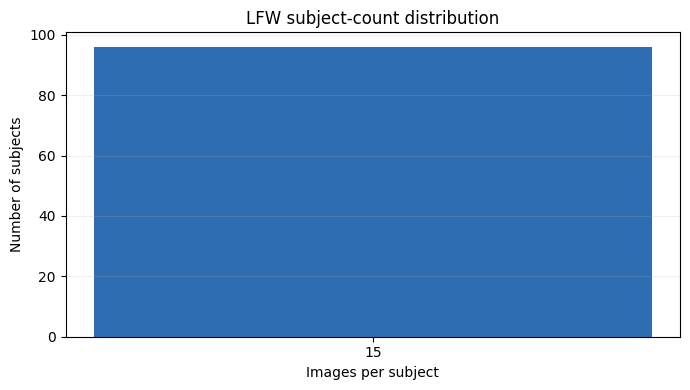

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(subject_count_hist["images_per_subject"].astype(str), subject_count_hist["num_subjects"], color="#2f6db2")
ax.set_xlabel("Images per subject")
ax.set_ylabel("Number of subjects")
ax.set_title("LFW subject-count distribution")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()

,count,count
Abdullah_Gul,12,3
Alejandro_Toledo,12,3
Alvaro_Uribe,12,3
Amelie_Mauresmo,12,3
Andre_Agassi,12,3
Andy_Roddick,12,3
Angelina_Jolie,12,3
Ariel_Sharon,12,3
Arnold_Schwarzenegger,12,3
Atal_Bihari_Vajpayee,12,3


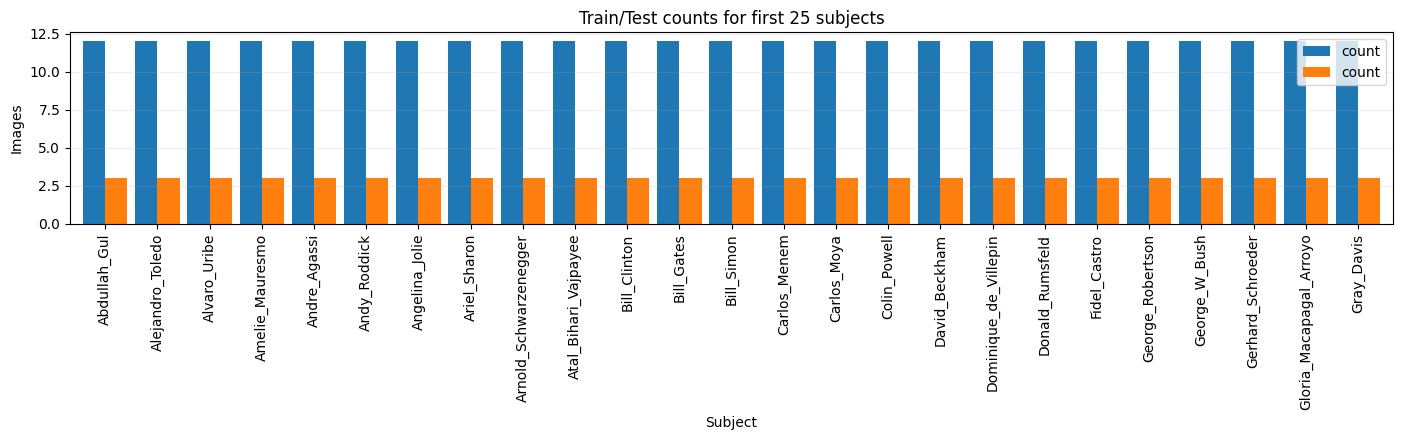

In [8]:
train_counts = pd.Series(processed["train_metadata"]["subject_names"], name="train").value_counts().sort_index()
test_counts = pd.Series(processed["test_metadata"]["subject_names"], name="test").value_counts().sort_index()
split_counts = pd.concat([train_counts, test_counts], axis=1).fillna(0).astype(int)

display(split_counts.head(20))

fig, ax = plt.subplots(figsize=(14, 4.5))
split_counts.head(25).plot(kind="bar", ax=ax, width=0.85)
ax.set_xlabel("Subject")
ax.set_ylabel("Images")
ax.set_title("Train/Test counts for first 25 subjects")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()

## Hien thi anh

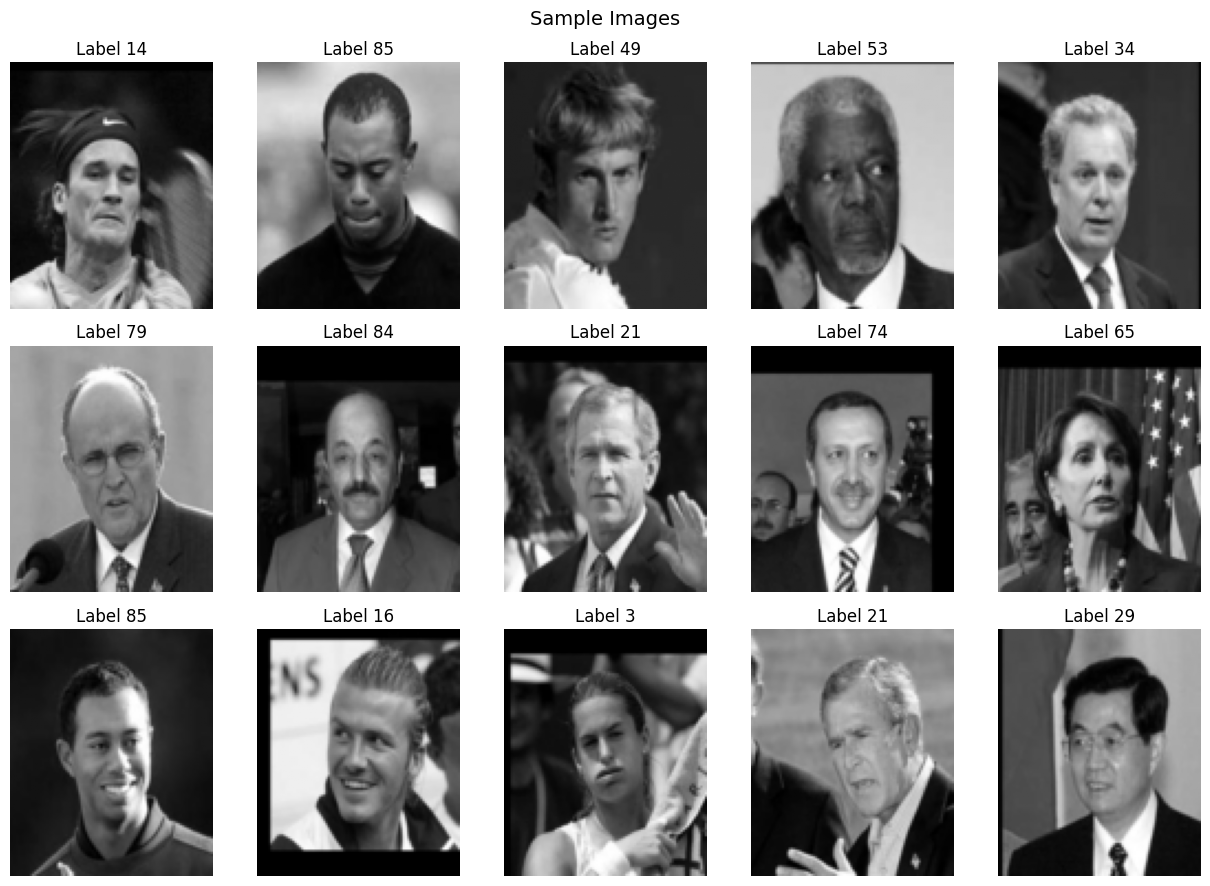

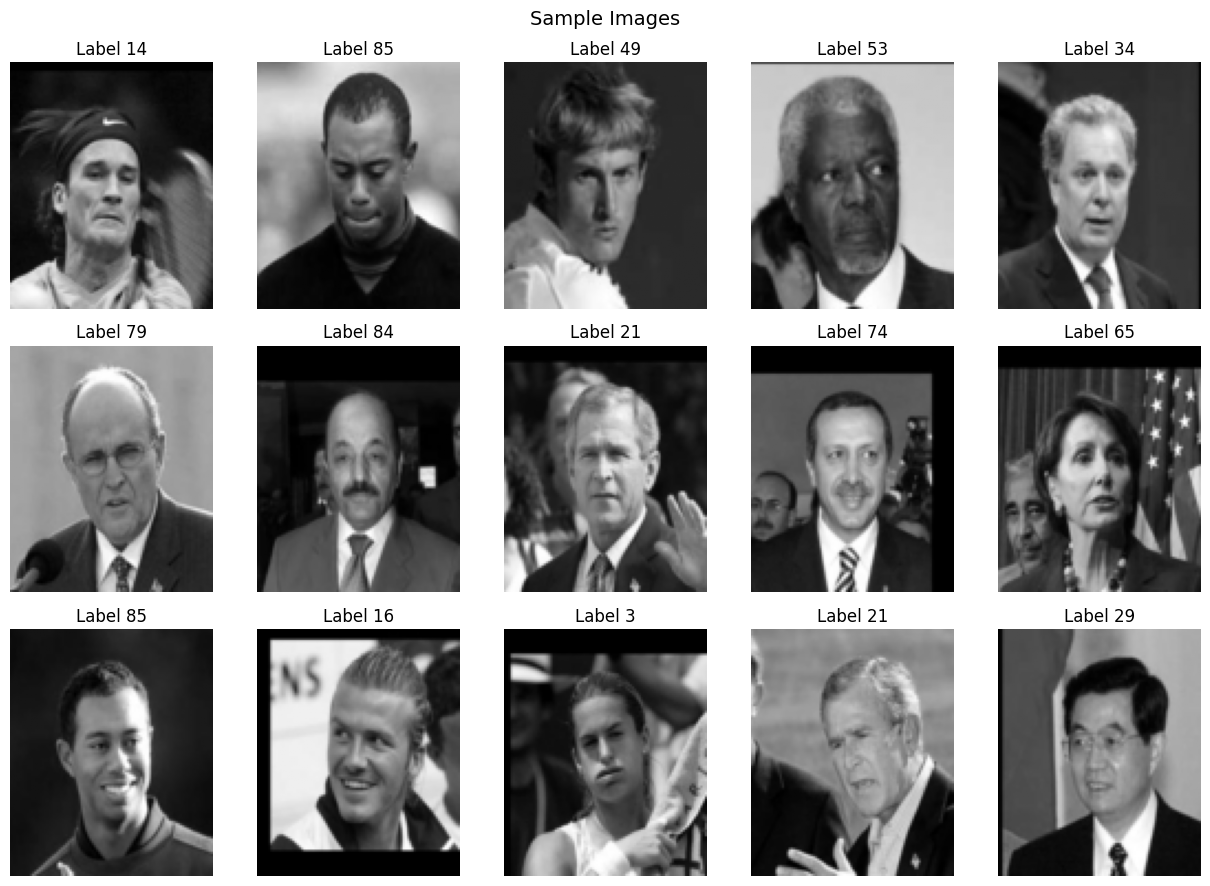

In [9]:
plot_sample_images(
    processed["X_train"],
    labels=processed["y_train"],
    n_samples=config["sample_grid_count"],
)

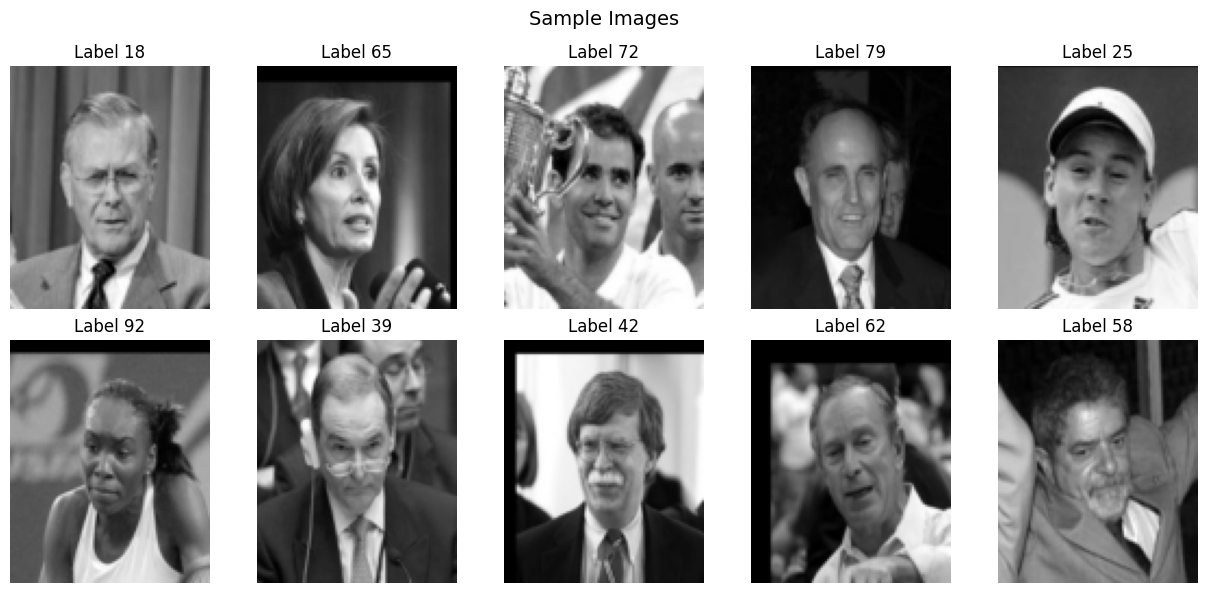

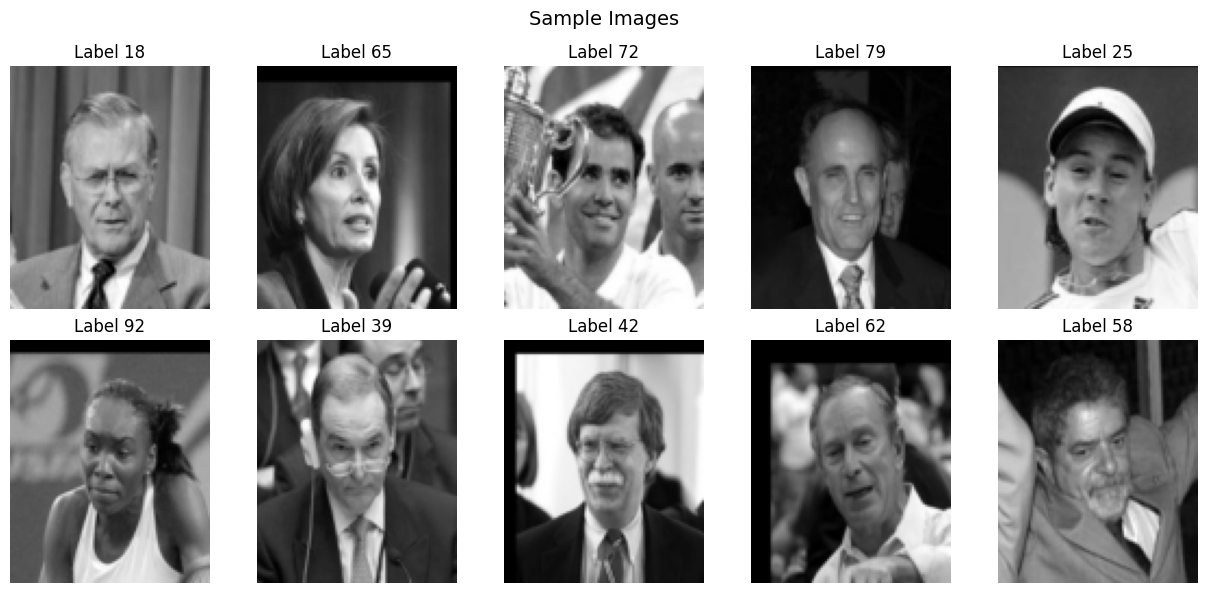

In [10]:
plot_sample_images(
    processed["X_test"],
    labels=processed["y_test"],
    n_samples=min(10, processed["X_test"].shape[0]),
)

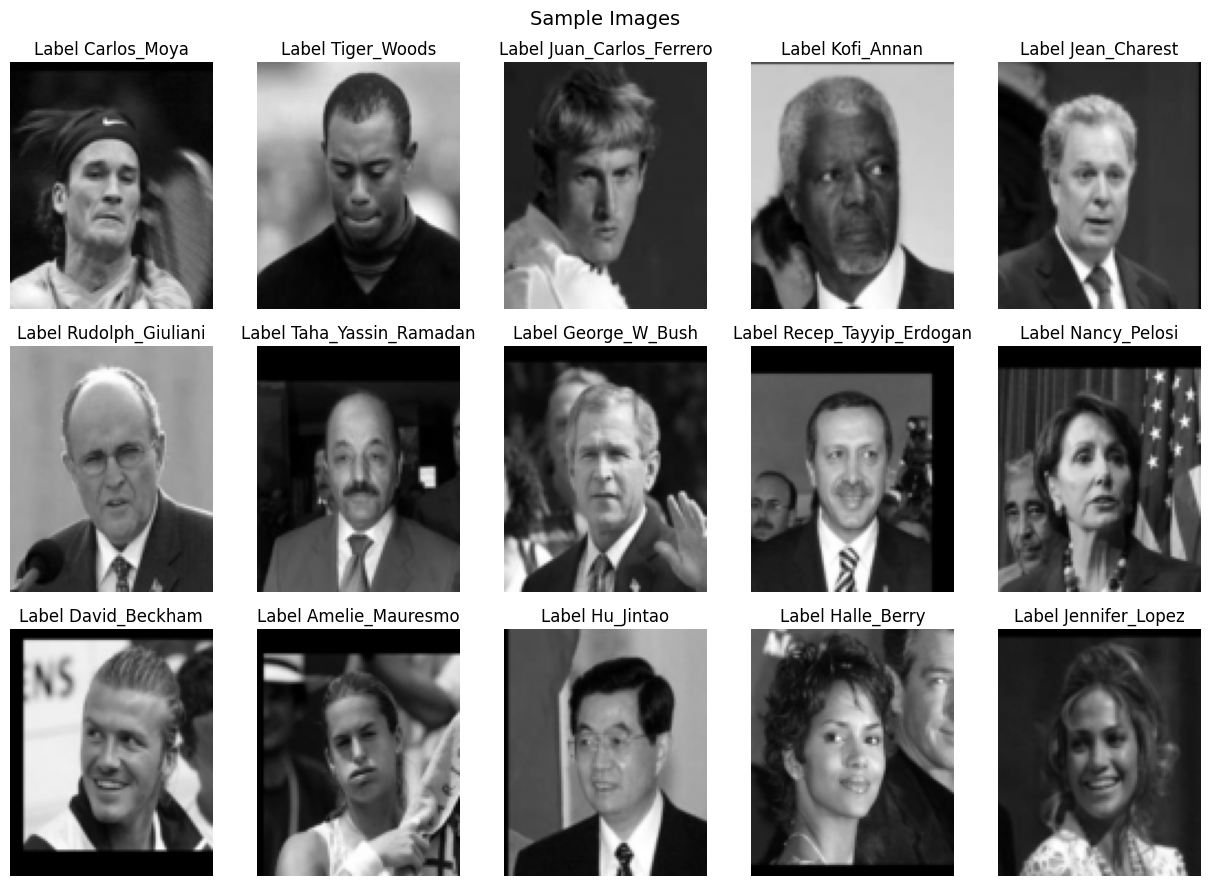

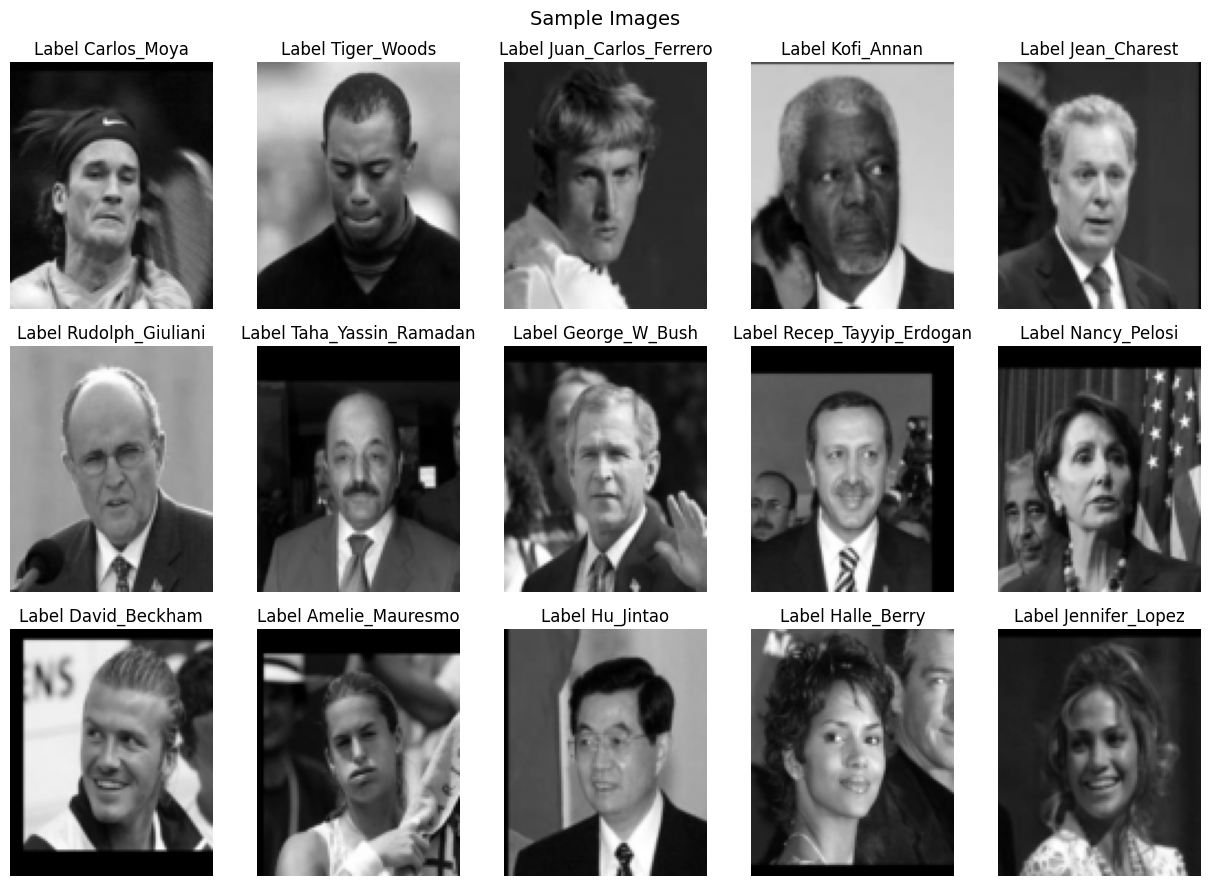

In [11]:
train_subject_names = processed["train_metadata"]["subject_names"]
representative_indices = []
seen_subjects = set()
for index, subject_name in enumerate(train_subject_names):
    if subject_name in seen_subjects:
        continue
    seen_subjects.add(subject_name)
    representative_indices.append(index)
    if len(representative_indices) >= config["sample_grid_count"]:
        break

representative_labels = np.asarray([train_subject_names[index] for index in representative_indices], dtype=object)
plot_sample_images(
    processed["X_train"][representative_indices],
    labels=representative_labels,
    n_samples=len(representative_indices),
)